### Identify whether particular cell types are enriched in the fetal reactivation hotspots

In [1]:
import scanpy as sc 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import glob
import os
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
plots_dir = "plots/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
from scipy.stats import gmean

def clr_transform(df, cols, eps=1e-6):
    X = df[cols].values + eps
    gm = gmean(X, axis=1)
    return pd.DataFrame(np.log(X / gm[:, None]), columns=cols, index=df.index)

In [4]:
res_df = pd.read_csv("Kuppe_Moran_I_results.csv", index_col = 0)

In [5]:
high_fetalization_samples = res_df[res_df['prop_fetalization_spots'] > 5]['sample']

In [6]:
high_fetalization_samples

0            Visium_IZ_P10
6            Visium_IZ_P15
7         Visium_GT_IZ_P13
8            Visium_FZ_P20
11         Visium_RZ_FZ_P5
12           Visium_FZ_P18
15         Visium_RZ_GT_P2
17         Visium_IZ_BZ_P2
19         Visium_GT_IZ_P9
20        Visium_FZ_GT_P19
21           Visium_FZ_P14
22    Visium_GT_IZ_P9_rep2
23           Visium_IZ_P16
24         Visium_FZ_GT_P4
26        Visium_GT_IZ_P15
Name: sample, dtype: object

In [7]:
diseased_sections = ["adata_with_weighted_fetalization_scores/" + high_fetal + ".h5ad" for high_fetal in high_fetalization_samples]

In [8]:
#diseased_sections = glob.glob("adata_with_weighted_fetalization_scores/*.h5ad")

In [9]:
cell_type_cols = ['Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Mast', 
                  'Myeloid', 'Neuronal', 'Pericyte', 'vSMC']

### Compute for all sections

In [10]:
def analyze_fetal_enrichment_pooled(adatas, cell_prop_cols, score_col, slide_key='slide'):

    # iterate through all of the adata files
    dfs = []
    for adata_path in adatas:
        adata = sc.read_h5ad(adata_path)
        tissue = adata_path.split('/')[-1].replace('.h5ad', '')
        df = adata.obs[cell_prop_cols + [score_col]].copy()
        df[slide_key] = tissue
        dfs.append(df)
    
    concat_df = pd.concat(dfs, axis=0, ignore_index=True)

    X = concat_df.loc[:,cell_prop_cols].copy()
    
    # perform centered log-ratio transformation
    X_clr = clr_transform(X, cell_prop_cols)

    # design matrix: cell proportions + slide fixed effects
    X_clr = sm.add_constant(X_clr)
    
    # slide fixed effects (controlling for slide-level baseline differences)
    slide_dummies = pd.get_dummies(concat_df[slide_key], drop_first=True, dtype=float)
    X = pd.concat([X_clr, slide_dummies], axis=1)
    
    # dependent variable is fetalization score
    y = concat_df[score_col].astype(float)
    X = X.astype(float)
    y = y.astype(float)
    
    # fit model
    model = sm.OLS(y, X).fit()
    
    # extract cell-type coefficients
    results = pd.DataFrame({
        'cell_type': cell_prop_cols,
        'coefficient': model.params[cell_prop_cols].values,
        'std_err': model.bse[cell_prop_cols].values,
        'p_value': model.pvalues[cell_prop_cols].values
    })
    
    # multiple testing correction
    results['adj_p_value'] = multipletests(results['p_value'], method='fdr_bh')[1]
    results['significant'] = results['adj_p_value'] < 0.05
    
    results = results.sort_values('coefficient', ascending=False).reset_index(drop=True)
    
    return concat_df, results, model

In [11]:
%%time
concat_df, pooled_results, pooled_model = analyze_fetal_enrichment_pooled(
    diseased_sections,
    cell_prop_cols=cell_type_cols,
    score_col='total_fetalization'
)

CPU times: user 1.94 s, sys: 3.97 s, total: 5.91 s
Wall time: 3.19 s


In [17]:
def plot_pooled_fetal_enrichment(pooled_results, cell_type_key="cell_type", fdr_thresh=0.05, figsize=(7, 5)):
    '''
    Plots pooled enrichment with cell types on the X-axis and coefficients on the Y-axis.
    '''
    
    df = pooled_results.copy()
    # sorting descending looks best for left-to-right bar/point flow
    df = df.sort_values("coefficient", ascending=False)

    df["significant"] = df["adj_p_value"] < fdr_thresh
    x_pos = np.arange(len(df))

    plt.figure(figsize=figsize)

    # plot error bars (yerr instead of xerr)
    plt.errorbar(x_pos, df["coefficient"],
                 yerr=df["std_err"],
                 fmt='o', capsize=3, linewidth=1, color='black')
    plt.axhline(0, ls="--", c="gray", alpha=0.7)
    plt.xticks(x_pos, df[cell_type_key], rotation=45, ha='right')
    plt.ylabel("Pooled standardized coefficient")
    plt.xlabel("Cell Type")
    plt.title("Cell type enrichment for fetalization spots")

    plt.legend()
    plt.tight_layout()
    return plt

/mnt/data1/william/tmp/ipykernel_1884350/1028053393.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


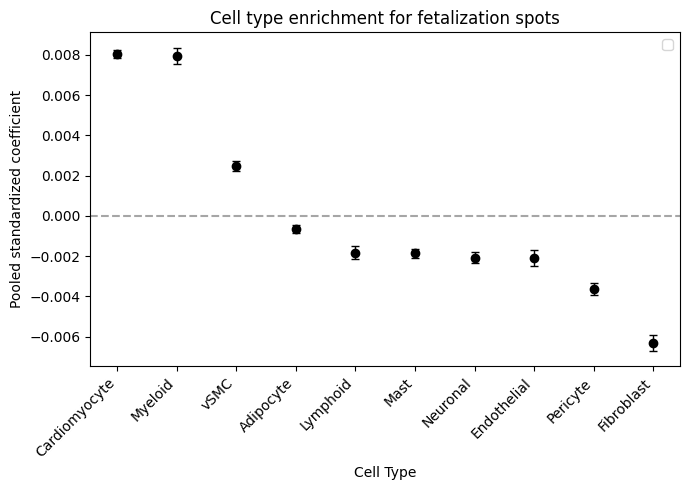

In [18]:
fetalization_plot = plot_pooled_fetal_enrichment(pooled_results)
fetalization_plot.savefig(plots_dir + "cell_type_enrichment_in_fetalization_spots.pdf")

In [14]:
def analyze_fetal_enrichment_pooled(adatas, cell_prop_cols, score_col, slide_key='slide'):
    # iterate through all of the adata files
    dfs = []
    for adata_path in adatas:
        adata = sc.read_h5ad(adata_path)
        tissue = adata_path.split('/')[-1].replace('.h5ad', '')
        df = adata.obs[cell_prop_cols + [score_col]].copy()
        df[slide_key] = tissue
        dfs.append(df)
    
    concat_df = pd.concat(dfs, axis=0, ignore_index=True)
    X = concat_df.loc[:,cell_prop_cols].copy()
    # perform centered log-ratio transformation
    X_clr = clr_transform(X, cell_prop_cols)
    # design matrix: cell proportions + slide fixed effects
    X_clr = sm.add_constant(X_clr)
    
    # slide fixed effects (controlling for slide-level baseline differences)
    slide_dummies = pd.get_dummies(concat_df[slide_key], drop_first=True, dtype=float)
    X = pd.concat([X_clr, slide_dummies], axis=1)
    
    # dependent variable is fetalization score
    y = concat_df[score_col].astype(float)
    X = X.astype(float)
    y = y.astype(float)
    
    # fit model
    model = sm.OLS(y, X).fit()
    
    # extract cell-type coefficients
    results = pd.DataFrame({
        'cell_type': cell_prop_cols,
        'coefficient': model.params[cell_prop_cols].values,
        'std_err': model.bse[cell_prop_cols].values,
        'p_value': model.pvalues[cell_prop_cols].values
    })
    
    # multiple testing correction
    results['adj_p_value'] = multipletests(results['p_value'], method='fdr_bh')[1]
    results['significant'] = results['adj_p_value'] < 0.05
    
    results = results.sort_values('coefficient', ascending=False).reset_index(drop=True)
    
    # per slide analysis
    per_slide_results = []
    
    for slide in concat_df[slide_key].unique():
        slide_df = concat_df[concat_df[slide_key] == slide].copy()
        
        # clr transform for this slide
        X_slide = slide_df.loc[:, cell_prop_cols].copy()
        X_slide_clr = clr_transform(X_slide, cell_prop_cols)
        X_slide_clr = sm.add_constant(X_slide_clr)
        
        # fit model for this slide
        y_slide = slide_df[score_col].astype(float)
        X_slide_clr = X_slide_clr.astype(float)
        
        model_slide = sm.OLS(y_slide, X_slide_clr).fit()
        
        # extract results
        slide_res = pd.DataFrame({
            'slide': slide,
            'cell_type': cell_prop_cols,
            'coefficient': model_slide.params[cell_prop_cols].values,
            'std_err': model_slide.bse[cell_prop_cols].values,
            'p_value': model_slide.pvalues[cell_prop_cols].values,
            'n_spots': len(slide_df)
        })
        
        # multiple testing correction per slide
        slide_res['adj_p_value'] = multipletests(slide_res['p_value'], method='fdr_bh')[1]
        slide_res['significant'] = slide_res['adj_p_value'] < 0.05
        
        per_slide_results.append(slide_res)
    
    per_slide_results = pd.concat(per_slide_results, axis=0, ignore_index=True)
    
    return concat_df, results, model, per_slide_results

In [15]:
concat_df, pooled_results, pooled_model, per_slide_results = analyze_fetal_enrichment_pooled(
    adatas=diseased_sections, 
    cell_prop_cols=cell_type_cols,
    score_col='total_fetalization'
)

### Visualize results per slide

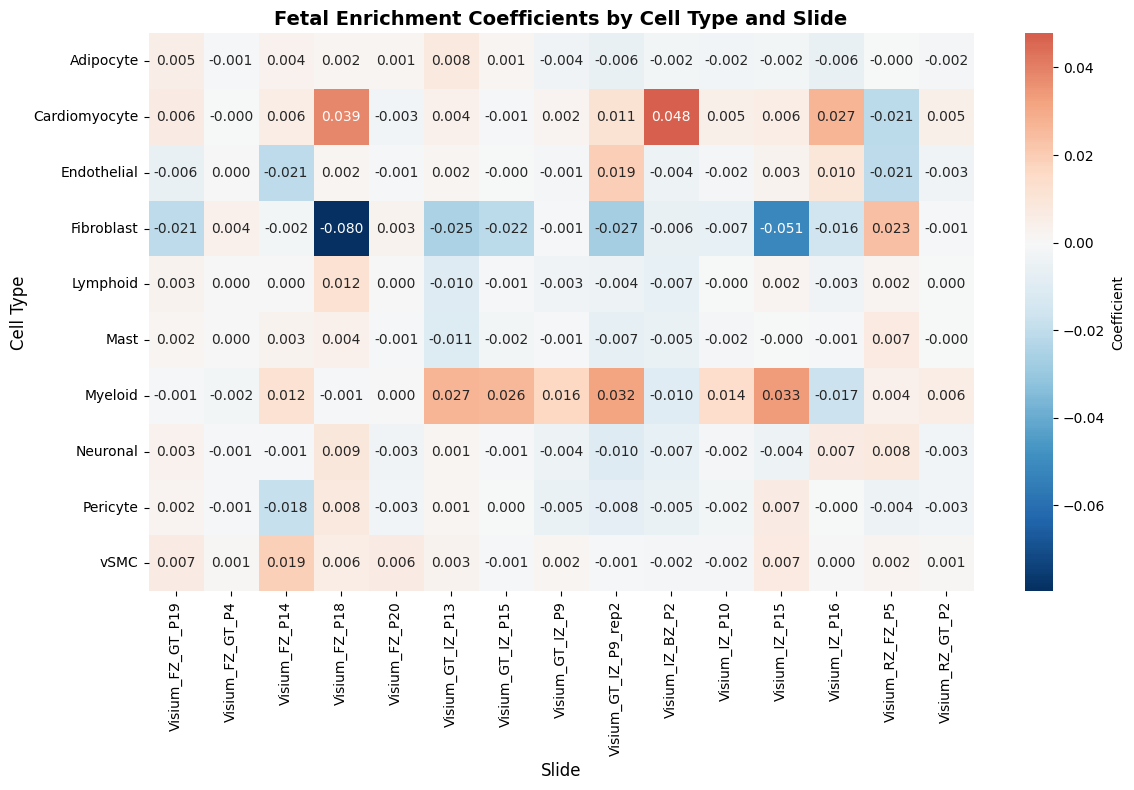

/mnt/data1/william/tmp/ipykernel_1884350/1980201147.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.005*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mask_data.iloc[i, j] = f"{mask_data.iloc[i, j]:.3f}*"
/mnt/data1/william/tmp/ipykernel_1884350/1980201147.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.001*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mask_data.iloc[i, j] = f"{mask_data.iloc[i, j]:.3f}*"
/mnt/data1/william/tmp/ipykernel_1884350/1980201147.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.004*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mask_data.iloc[i, j] = f"{mask

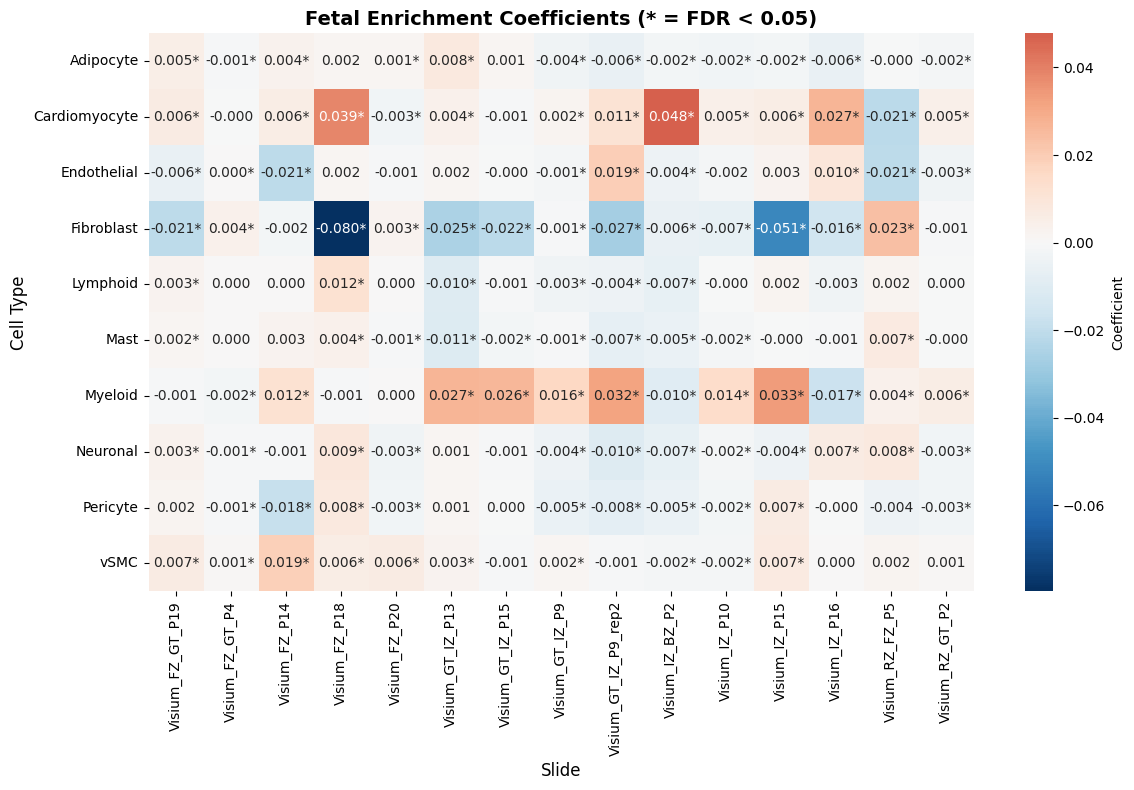

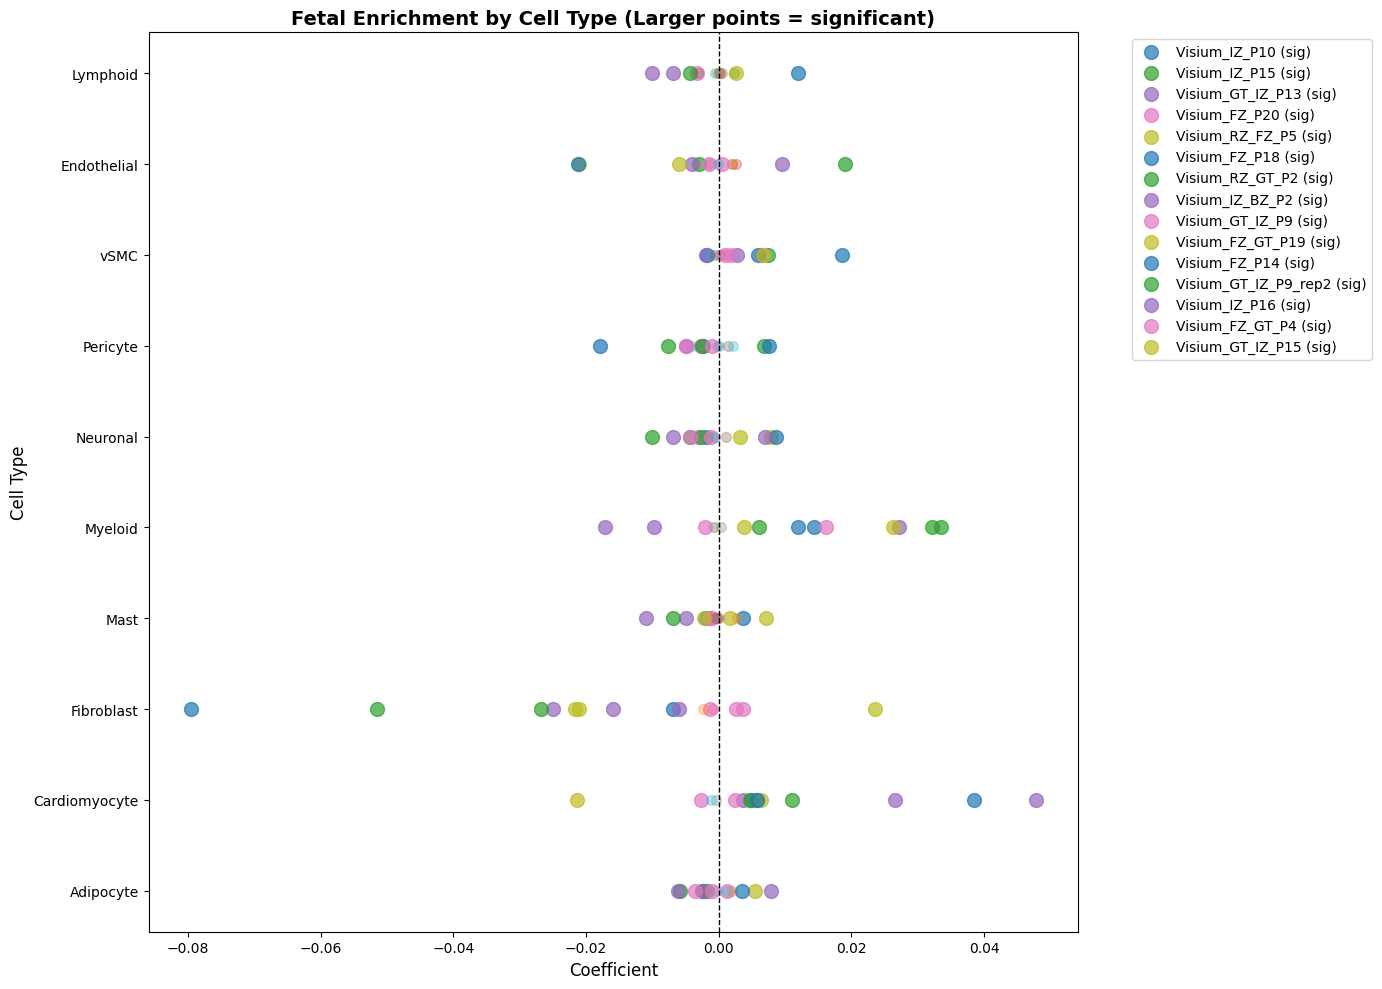

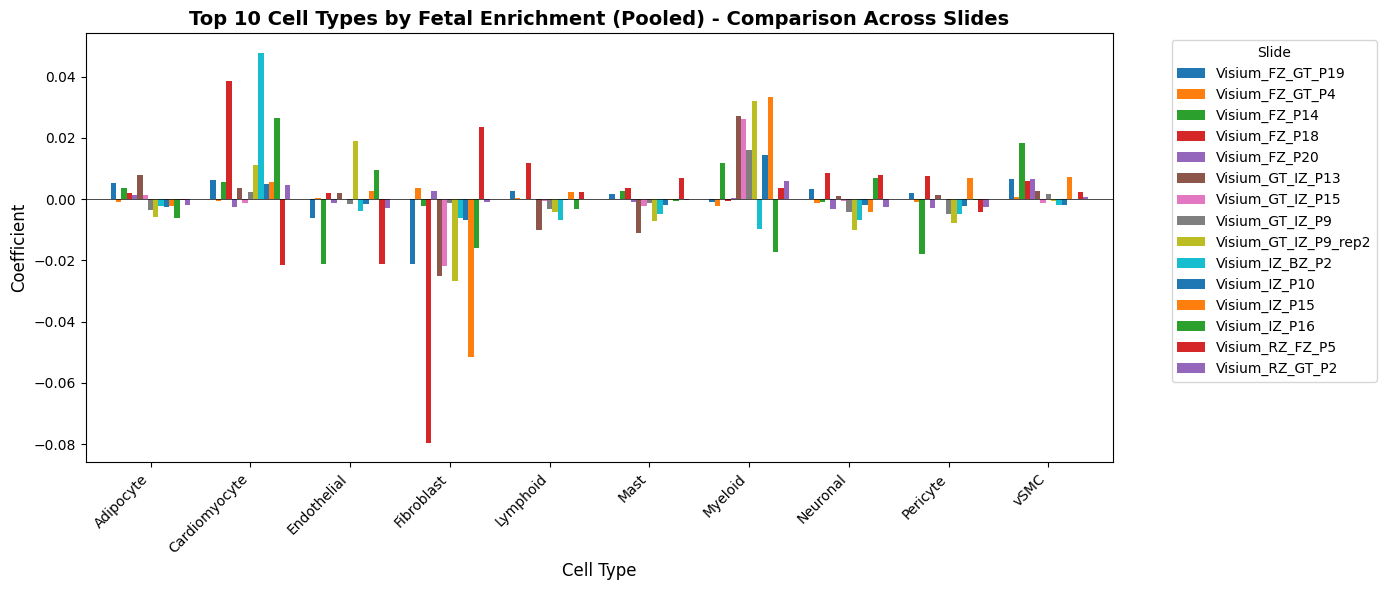


Visium_IZ_P10:
  Total spots: 3646
  Significant cell types: 8/10
  Top 3 positive:
    cell_type  coefficient  adj_p_value
      Myeloid     0.014363 1.177161e-70
Cardiomyocyte     0.004894 2.498728e-17
     Lymphoid    -0.000309 5.339571e-01

Visium_IZ_P15:
  Total spots: 3083
  Significant cell types: 7/10
  Top 3 positive:
cell_type  coefficient  adj_p_value
  Myeloid     0.033457 1.015631e-36
     vSMC     0.007354 2.572518e-13
 Pericyte     0.006831 6.140036e-08

Visium_GT_IZ_P13:
  Total spots: 1890
  Significant cell types: 7/10
  Top 3 positive:
    cell_type  coefficient  adj_p_value
      Myeloid     0.027170 3.841198e-32
    Adipocyte     0.007934 1.970521e-04
Cardiomyocyte     0.003658 8.522508e-15

Visium_FZ_P20:
  Total spots: 2410
  Significant cell types: 7/10
  Top 3 positive:
 cell_type  coefficient  adj_p_value
      vSMC     0.006491 2.681365e-30
Fibroblast     0.002543 6.538350e-03
 Adipocyte     0.001270 1.275825e-03

Visium_RZ_FZ_P5:
  Total spots: 3082
  Signi

In [16]:
# heatmap of coefficients across slides
fig, ax = plt.subplots(figsize=(12, 8))

# pivot data for heatmap
heatmap_data = per_slide_results.pivot(index='cell_type', columns='slide', values='coefficient')

sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, annot=True, fmt='.3f', 
            cbar_kws={'label': 'Coefficient'}, ax=ax)
plt.title('Fetal Enrichment Coefficients by Cell Type and Slide', fontsize=14, fontweight='bold')
plt.xlabel('Slide', fontsize=12)
plt.ylabel('Cell Type', fontsize=12)
plt.tight_layout()
plt.show()

# heatmap with significance markers
fig, ax = plt.subplots(figsize=(12, 8))
# pivot significance
sig_data = per_slide_results.pivot(index='cell_type', columns='slide', values='significant')

# create mask for non-significant values
mask_data = heatmap_data.copy()
for i, cell_type in enumerate(mask_data.index):
    for j, slide in enumerate(mask_data.columns):
        if sig_data.loc[cell_type, slide]:
            mask_data.iloc[i, j] = f"{mask_data.iloc[i, j]:.3f}*"
        else:
            mask_data.iloc[i, j] = f"{mask_data.iloc[i, j]:.3f}"

sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, annot=mask_data, fmt='', 
            cbar_kws={'label': 'Coefficient'}, ax=ax)
plt.title('Fetal Enrichment Coefficients (* = FDR < 0.05)', fontsize=14, fontweight='bold')
plt.xlabel('Slide', fontsize=12)
plt.ylabel('Cell Type', fontsize=12)
plt.tight_layout()
plt.show()

# dot plot showing coefficients and significance
fig, ax = plt.subplots(figsize=(14, 10))

# add slide as numeric for plotting
per_slide_results['slide_num'] = pd.Categorical(per_slide_results['slide']).codes

# create dot plot
for slide in per_slide_results['slide'].unique():
    slide_data = per_slide_results[per_slide_results['slide'] == slide]
    sig = slide_data[slide_data['significant']]
    non_sig = slide_data[~slide_data['significant']]
    
    # plot significant points
    ax.scatter(sig['coefficient'], sig['cell_type'], s=100, alpha=0.7, label=f'{slide} (sig)')
    # Plot non-significant points
    ax.scatter(non_sig['coefficient'], non_sig['cell_type'], s=50, alpha=0.3, marker='o')

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_title('Fetal Enrichment by Cell Type (Larger points = significant)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# produce bar plot comparing top cell types across slides
top_n = 10
top_cells = pooled_results.head(top_n)['cell_type'].values

fig, ax = plt.subplots(figsize=(14, 6))

slide_data = per_slide_results[per_slide_results['cell_type'].isin(top_cells)]
slide_pivot = slide_data.pivot(index='cell_type', columns='slide', values='coefficient')

slide_pivot.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Cell Type', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title(f'Top {top_n} Cell Types by Fetal Enrichment (Pooled) - Comparison Across Slides', 
             fontsize=14, fontweight='bold')
ax.legend(title='Slide', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 
for slide in per_slide_results['slide'].unique():
    slide_data = per_slide_results[per_slide_results['slide'] == slide]
    n_sig = slide_data['significant'].sum()
    n_total = len(slide_data)
    print(f"\n{slide}:")
    print(f"  Total spots: {slide_data['n_spots'].iloc[0]}")
    print(f"  Significant cell types: {n_sig}/{n_total}")
    print(f"  Top 3 positive:")
    top3 = slide_data.nlargest(3, 'coefficient')[['cell_type', 'coefficient', 'adj_p_value']]
    print(top3.to_string(index=False))